In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd

In [2]:
import os
for dirname, _, filenames in os.walk('/content'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/content/.config/.last_survey_prompt.yaml
/content/.config/.last_update_check.json
/content/.config/gce
/content/.config/active_config
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/.last_opt_in_prompt.yaml
/content/.config/default_configs.db
/content/.config/config_sentinel
/content/.config/logs/2026.03.17/17.57.52.612495.log
/content/.config/logs/2026.03.17/17.58.05.704278.log
/content/.config/logs/2026.03.17/17.58.04.875109.log
/content/.config/logs/2026.03.17/17.57.19.158613.log
/content/.config/logs/2026.03.17/17.57.42.186318.log
/content/.config/logs/2026.03.17/17.57.53.918018.log
/content/.config/configurations/config_default
/content/sample_data/README.md
/content/sample_data/anscombe.json
/content/sample_data/california_housing_test.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/mnist_test.csv


In [3]:
# Lord dataset from csv file
df = pd.read_csv('/content/ecommerce_furniture_dataset_2024.csv', encoding='latin1')


FileNotFoundError: [Errno 2] No such file or directory: '/content/ecommerce_furniture_dataset_2024.csv'

In [ ]:
# View the first few rows of the dataset
print(df.head())

                                        productTitle originalPrice    price  \
0  Dresser For Bedroom With 9 Fabric Drawers Ward...           NaN   $46.79   
1  Outdoor Conversation Set 4 Pieces Patio Furnit...           NaN  $169.72   
2  Dresser For Bedroom With 7 Fabric Drawers Orga...        $78.40   $39.46   
3  Modern Accent Boucle Chair, Upholstered Tufted...           NaN  $111.99   
4  Small Unit Simple Computer Desk Household Wood...        $48.82   $21.37   

    sold        tagText  
0  600.0  Free Shipping  
1    0.0  Free Shipping  
2    7.0  Free Shipping  
3    0.0  Free Shipping  
4    1.0  Free Shipping  


In [ ]:
# Check for missing values
print(df.isnull().sum())

productTitle        0
originalPrice    1536
price               6
sold                1
tagText             1
dtype: int64


In [ ]:
df.shape

(2000, 5)

In [ ]:
# Dropping any rows with missing values (if applicable)
df.drop(['originalPrice'],axis=1,inplace=True)

In [ ]:
df.head()

,productTitle,price,sold,tagText
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,$46.79,600.0,Free Shipping
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,$169.72,0.0,Free Shipping
2,Dresser For Bedroom With 7 Fabric Drawers Orga...,$39.46,7.0,Free Shipping
3,"Modern Accent Boucle Chair, Upholstered Tufted...",$111.99,0.0,Free Shipping
4,Small Unit Simple Computer Desk Household Wood...,$21.37,1.0,Free Shipping


In [ ]:
df['tagText'].nunique()

96

In [ ]:
df['tagText'].value_counts()

,count
tagText,
Free Shipping,1886
$5.09,9
$239.64,2
$80.21,2
$94.92,2
...,...
$134.27,1
$151.69,1
$41.93,1


In [ ]:
df['tagText'] = df['tagText'].apply(lambda x: x if x in ['Free Shipping', '+Shipping: $5.09'] else 'others')
print((df['tagText'].value_counts()))

tagText
Free Shipping    1886
others            114
Name: count, dtype: int64


In [ ]:
# importing another libraries
import seaborn as sns

<Axes: xlabel='tagText', ylabel='count'>

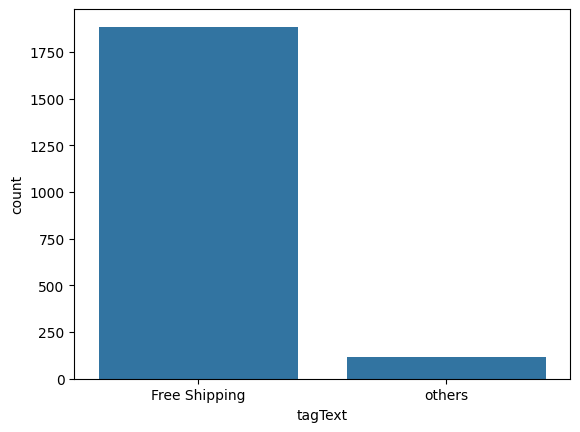

In [ ]:
sns.countplot(x = 'tagText', data = df)

In [ ]:
# Step 1: Remove $ and split by tab (\t), then take the first part as the price
df['price_clean'] = df['price'].str.replace('$', '', regex=False).str.split('\t').str[0]

# Step 2: Convert the cleaned price to float
df['price_clean'] = df['price_clean'].astype(float)


In [ ]:
df['price'] = df['price'].str.replace('$', '', regex=False).str.split('\t').str[0].astype(float)

In [ ]:
df.head()

,productTitle,price,sold,tagText,price_clean
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,46.79,600.0,Free Shipping,46.79
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,169.72,0.0,Free Shipping,169.72
2,Dresser For Bedroom With 7 Fabric Drawers Orga...,39.46,7.0,Free Shipping,39.46
3,"Modern Accent Boucle Chair, Upholstered Tufted...",111.99,0.0,Free Shipping,111.99
4,Small Unit Simple Computer Desk Household Wood...,21.37,1.0,Free Shipping,21.37


In [ ]:
df.drop(['price_clean'],axis=1,inplace=True)

In [ ]:
df.head()

,productTitle,price,sold,tagText
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,46.79,600.0,Free Shipping
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,169.72,0.0,Free Shipping
2,Dresser For Bedroom With 7 Fabric Drawers Orga...,39.46,7.0,Free Shipping
3,"Modern Accent Boucle Chair, Upholstered Tufted...",111.99,0.0,Free Shipping
4,Small Unit Simple Computer Desk Household Wood...,21.37,1.0,Free Shipping


<ipython-input-35-86c1ddc3c66a>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

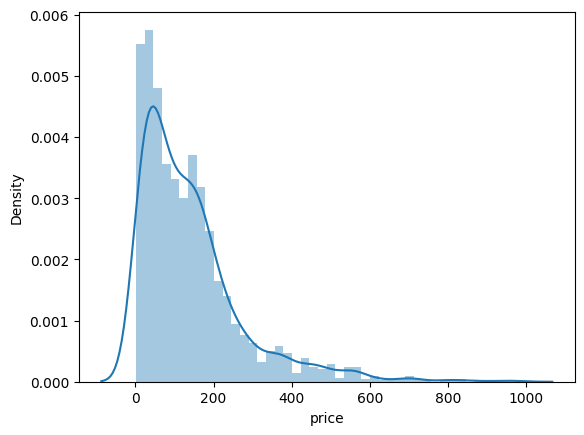

In [ ]:
sns.distplot(df['price'])

<ipython-input-36-17cdf52c425f>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['sold'])


<Axes: xlabel='sold', ylabel='Density'>

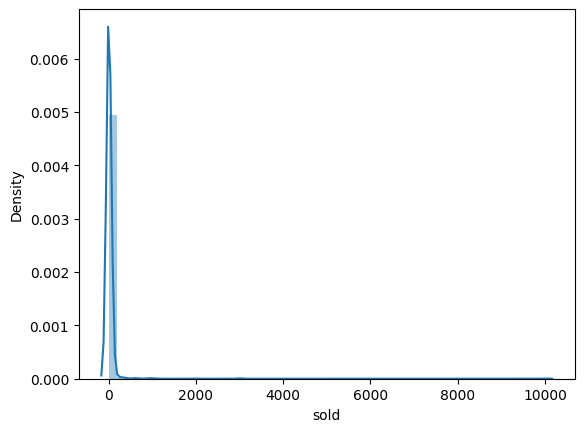

In [ ]:
sns.distplot(df['sold'])

<Axes: xlabel='price', ylabel='sold'>

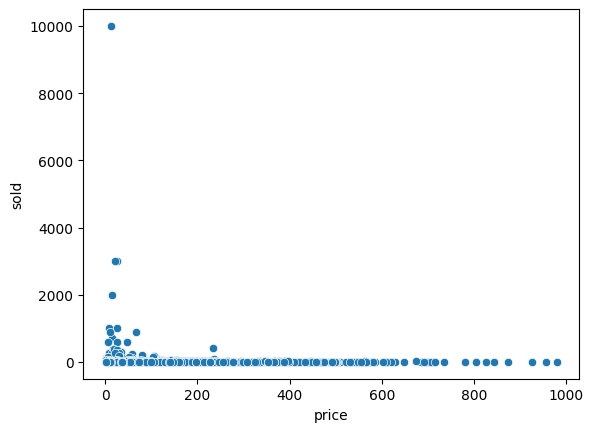

In [ ]:
sns.scatterplot(x='price', y='sold', data=df)

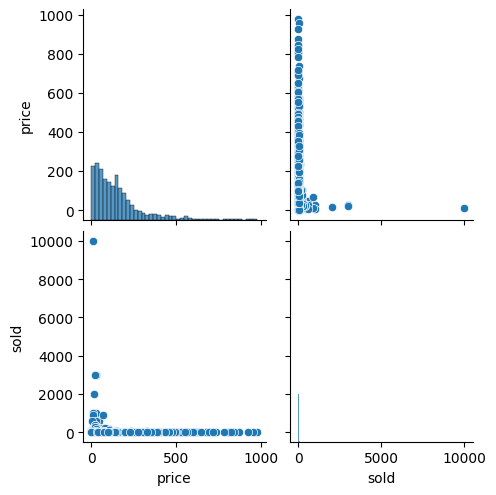

In [ ]:
filtered_df = df[df['tagText'] == 'Free Shipping']

# Create a pairplot including the 'sold' column and other relevent column
sns.pairplot(filtered_df[['price', 'sold']])

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['tagText']=le.fit_transform(df['tagText'])

In [ ]:
df.head()

,productTitle,price,sold,tagText
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,46.79,600.0,0
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,169.72,0.0,0
2,Dresser For Bedroom With 7 Fabric Drawers Orga...,39.46,7.0,0
3,"Modern Accent Boucle Chair, Upholstered Tufted...",111.99,0.0,0
4,Small Unit Simple Computer Desk Household Wood...,21.37,1.0,0


In [ ]:
df['tagText'].value_counts()

,count
tagText,
0,1886
1,114
